# Post Pandemic Regime Shifts in Labor Market: Exploratory Data Analysis

## Purpose
### Problem Statement
### Objective
### Scope and Limitations

## Research Context

## Imports and Configuration

In [1]:
%matplotlib inline
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import t as t_dist
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams["figure.figsize"] = (14, 8)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 50)
sns.set_theme(style="whitegrid")

In [4]:
from regime_shift.config import (
    MERGED_DATA_PATH,
    FEATURE_ENGINEERED_DATA_PATH,
    REPORTS_DIR,
    FIGURES_DIR,
    REGIME_BREAKS,
    QUANDT_BREAKPOINT,
    LABOR_MARKET_VARIABLES,
    WAGE_VARIABLES,
    INFLATION_VARIABLES,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

## Load Dataset

In [9]:
df = pd.read_csv(MERGED_DATA_PATH)

print(df.shape)
df.info()

(315, 136)
<class 'pandas.DataFrame'>
RangeIndex: 315 entries, 0 to 314
Columns: 136 entries, date to exp_5yr_cpi
dtypes: float64(135), str(1)
memory usage: 337.9 KB


## Data Overview

In [15]:
df.head(3)

,date,job_openings_level,hires_rate,hires_level,quits_rate,quits_level,total_separations_rate,total_separations_level,layoffs_discharges_level,layoffs_discharges_rate,unemployment_rate,unemployment_level,u6_rate,prime_age_lfpr,lfpr,epop_ratio,prime_age_urate,avg_weeks_unemployed,payrolls_nonfarm,payrolls_private,payrolls_manufacturing,payrolls_services,payrolls_construction,ahe_private,awe_private,awh_private,awe_manufacturing,ahe_manufacturing,eci_total,eci_wages,cpi_all,cpi_core,cpi_less_shelter,cpi_services_less_rent,cpi_services_less_energy,cpi_shelter,cpi_medical,cpi_food,pce_price,pce_core,pce_trimmed_12m,pce_trimmed_1m,pce_services,saving_rate,real_dpi,real_pi,real_pi_less_transfers,retail_advance,real_retail,ip_total,...,atl_..7,atl_..8,atl_..9,atl_..10,atl_..11,atl_..12,atl_..13,atl_..14,atl_..15,phl_ruc_RUC15Q1,phl_ruc_RUC15Q2,phl_ruc_RUC15Q3,phl_ruc_RUC15Q4,phl_ruc_RUC16Q1,phl_ruc_RUC16Q2,phl_ruc_RUC16Q3,phl_ruc_RUC16Q4,phl_ruc_RUC17Q1,phl_ruc_RUC17Q2,phl_ruc_RUC17Q3,phl_ruc_RUC17Q4,phl_ruc_RUC18Q1,phl_ruc_RUC18Q2,phl_ruc_RUC18Q3,phl_ruc_RUC18Q4,phl_ruc_RUC19Q1,phl_ruc_RUC19Q2,phl_ruc_RUC19Q3,phl_ruc_RUC19Q4,phl_cpi_CPI15Q1,phl_cpi_CPI15Q2,phl_cpi_CPI15Q3,phl_cpi_CPI15Q4,phl_cpi_CPI16Q1,phl_cpi_CPI16Q2,phl_cpi_CPI16Q3,phl_cpi_CPI16Q4,phl_cpi_CPI17Q1,phl_cpi_CPI17Q2,phl_cpi_CPI17Q3,phl_cpi_CPI17Q4,phl_cpi_CPI18Q1,phl_cpi_CPI18Q2,phl_cpi_CPI18Q3,phl_cpi_CPI18Q4,phl_cpi_CPI19Q1,phl_cpi_CPI19Q2,phl_cpi_CPI19Q3,phl_cpi_CPI19Q4,exp_5yr_cpi
0,2000-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,5708.0,7.0,84.4,67.3,64.6,12.7,13.1,131011.0,110440.0,17284.0,106382.0,6752.0,NaN,NaN,NaN,14.12,NaN,NaN,NaN,169.3,179.3,162.8,198.6,199.2,180.9,255.6,165.6,72.961,74.306,2.00,3.20,64.396,324.2,9799.9,11441.669,10000.3,261545.0,154486.0,91.5380,...,4.5,5.8,4.6,5.1,5.1,5.6,4.9,5.0,4.8,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,169.3,169.3,169.3,169.3,169.3,169.3,169.3,169.3,169.3,169.3,169.3,169.3,169.3,169.3,169.3,169.3,169.3,169.3,169.3,169.3,NaN
1,2000-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.1,5858.0,7.1,84.4,67.3,64.6,10.8,12.6,131120.0,110521.0,17284.0,106512.0,6730.0,NaN,NaN,NaN,14.14,NaN,NaN,NaN,170.0,179.4,163.6,199.2,199.5,181.3,256.5,166.2,73.191,74.415,2.12,2.36,64.588,289.4,9837.9,11488.814,10045.9,265686.0,156286.0,91.8239,...,4.4,5.7,4.6,5.1,5.1,5.6,4.8,5.0,4.7,4.1,4.1,4.1,4.1,4.1,4.1,4.1,4.1,4.1,4.1,4.1,4.1,4.1,4.1,4.1,4.1,4.1,4.1,4.1,4.1,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,NaN
2,2000-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,5733.0,7.1,84.3,67.3,64.6,11.0,12.7,131604.0,110871.0,17302.0,106898.0,6811.0,NaN,NaN,NaN,14.17,NaN,NaN,NaN,171.0,180.0,164.7,199.9,200.2,181.9,257.7,166.5,73.505,74.568,2.24,2.86,64.703,276.5,9864.0,11520.777,10078.6,269019.0,157321.0,92.1504,...,4.4,5.6,4.4,5.0,5.0,5.4,4.8,5.1,4.6,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,171.0,171.0,171.0,171.0,171.0,171.0,171.0,171.0,171.0,171.0,171.0,171.0,171.0,171.0,171.0,171.0,171.0,171.0,171.0,171.0,NaN


In [16]:
df.tail(3)

,date,job_openings_level,hires_rate,hires_level,quits_rate,quits_level,total_separations_rate,total_separations_level,layoffs_discharges_level,layoffs_discharges_rate,unemployment_rate,unemployment_level,u6_rate,prime_age_lfpr,lfpr,epop_ratio,prime_age_urate,avg_weeks_unemployed,payrolls_nonfarm,payrolls_private,payrolls_manufacturing,payrolls_services,payrolls_construction,ahe_private,awe_private,awh_private,awe_manufacturing,ahe_manufacturing,eci_total,eci_wages,cpi_all,cpi_core,cpi_less_shelter,cpi_services_less_rent,cpi_services_less_energy,cpi_shelter,cpi_medical,cpi_food,pce_price,pce_core,pce_trimmed_12m,pce_trimmed_1m,pce_services,saving_rate,real_dpi,real_pi,real_pi_less_transfers,retail_advance,real_retail,ip_total,...,atl_..7,atl_..8,atl_..9,atl_..10,atl_..11,atl_..12,atl_..13,atl_..14,atl_..15,phl_ruc_RUC15Q1,phl_ruc_RUC15Q2,phl_ruc_RUC15Q3,phl_ruc_RUC15Q4,phl_ruc_RUC16Q1,phl_ruc_RUC16Q2,phl_ruc_RUC16Q3,phl_ruc_RUC16Q4,phl_ruc_RUC17Q1,phl_ruc_RUC17Q2,phl_ruc_RUC17Q3,phl_ruc_RUC17Q4,phl_ruc_RUC18Q1,phl_ruc_RUC18Q2,phl_ruc_RUC18Q3,phl_ruc_RUC18Q4,phl_ruc_RUC19Q1,phl_ruc_RUC19Q2,phl_ruc_RUC19Q3,phl_ruc_RUC19Q4,phl_cpi_CPI15Q1,phl_cpi_CPI15Q2,phl_cpi_CPI15Q3,phl_cpi_CPI15Q4,phl_cpi_CPI16Q1,phl_cpi_CPI16Q2,phl_cpi_CPI16Q3,phl_cpi_CPI16Q4,phl_cpi_CPI17Q1,phl_cpi_CPI17Q2,phl_cpi_CPI17Q3,phl_cpi_CPI17Q4,phl_cpi_CPI18Q1,phl_cpi_CPI18Q2,phl_cpi_CPI18Q3,phl_cpi_CPI18Q4,phl_cpi_CPI19Q1,phl_cpi_CPI19Q2,phl_cpi_CPI19Q3,phl_cpi_CPI19Q4,exp_5yr_cpi
312,2026-01-01,7240.0,3.4,5347.0,2.0,3131.0,3.2,5144.0,1660.0,1.0,4.3,7368.0,8.1,84.0,62.1,59.4,24.7,23.7,158558.0,135229.0,12585.0,137051.0,8320.0,37.17,1274.93,34.3,29.60,36.20,NaN,NaN,326.588,332.793,292.861,439.057,438.784,441.285,589.610,345.271,128.969,128.394,2.43,2.72,135.19,1054.7,18203.2,20701.805,16740.9,733537.0,224606.0,102.3963,...,3.5,4.7,3.7,3.6,3.7,3.7,3.6,3.7,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.4437
313,2026-02-01,6882.0,3.1,4849.0,1.9,2974.0,3.1,4971.0,1721.0,1.1,4.4,7571.0,7.9,83.9,62.0,59.3,25.3,25.7,158466.0,135143.0,12573.0,136984.0,8309.0,37.32,1280.08,34.3,29.77,36.39,NaN,NaN,327.460,333.512,293.701,440.876,439.959,441.865,592.554,346.622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.5510,...,3.6,4.7,3.5,3.8,4.0,3.9,3.5,3.5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
314,2026-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.describe()

,job_openings_level,hires_rate,hires_level,quits_rate,quits_level,total_separations_rate,total_separations_level,layoffs_discharges_level,layoffs_discharges_rate,unemployment_rate,unemployment_level,u6_rate,prime_age_lfpr,lfpr,epop_ratio,prime_age_urate,avg_weeks_unemployed,payrolls_nonfarm,payrolls_private,payrolls_manufacturing,payrolls_services,payrolls_construction,ahe_private,awe_private,awh_private,awe_manufacturing,ahe_manufacturing,eci_total,eci_wages,cpi_all,cpi_core,cpi_less_shelter,cpi_services_less_rent,cpi_services_less_energy,cpi_shelter,cpi_medical,cpi_food,pce_price,pce_core,pce_trimmed_12m,pce_trimmed_1m,pce_services,saving_rate,real_dpi,real_pi,real_pi_less_transfers,retail_advance,real_retail,ip_total,ip_manufacturing,...,atl_..7,atl_..8,atl_..9,atl_..10,atl_..11,atl_..12,atl_..13,atl_..14,atl_..15,phl_ruc_RUC15Q1,phl_ruc_RUC15Q2,phl_ruc_RUC15Q3,phl_ruc_RUC15Q4,phl_ruc_RUC16Q1,phl_ruc_RUC16Q2,phl_ruc_RUC16Q3,phl_ruc_RUC16Q4,phl_ruc_RUC17Q1,phl_ruc_RUC17Q2,phl_ruc_RUC17Q3,phl_ruc_RUC17Q4,phl_ruc_RUC18Q1,phl_ruc_RUC18Q2,phl_ruc_RUC18Q3,phl_ruc_RUC18Q4,phl_ruc_RUC19Q1,phl_ruc_RUC19Q2,phl_ruc_RUC19Q3,phl_ruc_RUC19Q4,phl_cpi_CPI15Q1,phl_cpi_CPI15Q2,phl_cpi_CPI15Q3,phl_cpi_CPI15Q4,phl_cpi_CPI16Q1,phl_cpi_CPI16Q2,phl_cpi_CPI16Q3,phl_cpi_CPI16Q4,phl_cpi_CPI17Q1,phl_cpi_CPI17Q2,phl_cpi_CPI17Q3,phl_cpi_CPI17Q4,phl_cpi_CPI18Q1,phl_cpi_CPI18Q2,phl_cpi_CPI18Q3,phl_cpi_CPI18Q4,phl_cpi_CPI19Q1,phl_cpi_CPI19Q2,phl_cpi_CPI19Q3,phl_cpi_CPI19Q4,exp_5yr_cpi
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,313.000000,313.000000,313.000000,313.000000,313.00000,313.000000,313.000000,313.000000,314.000000,314.000000,314.000000,314.000000,314.000000,240.000000,240.000000,240.000000,314.000000,240.000000,298.000000,298.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,312.000000,314.000000,314.000000,...,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,181.000000,184.00000,187.000000,190.000000,193.000000,196.000000,199.000000,202.000000,205.000000,208.000000,211.000000,214.000000,217.000000,220.000000,223.000000,226.000000,229.000000,232.000000,235.000000,238.000000,180.000000,183.000000,186.000000,189.000000,192.000000,195.000000,198.000000,201.000000,205.000000,208.000000,211.000000,214.000000,217.000000,220.000000,223.000000,226.000000,229.000000,232.000000,235.000000,238.000000,83.00000
mean,5480.343234,3.681848,5187.729373,2.008911,2849.300330,3.615512,5098.303630,1906.841584,1.360726,5.636102,8759.063898,10.214696,82.413099,64.16901,60.549201,25.108626,23.800319,140538.949045,118400.872611,13170.178344,119736.407643,6948.671975,26.738583,919.732417,34.389167,19.984586,26.693125,122.258584,122.661386,233.774613,238.984102,219.023866,303.209259,295.057508,282.282581,419.550677,237.494716,95.765351,95.402435,2.218339,2.225495,93.191163,808.655591,13632.707668,15485.599751,12836.477955,436965.923323,182861.134615,97.267287,97.031202,...,3.444089,4.086262,3.509904,3.811821,3.950799,3.818530,3.679872,3.808307,3.566773,6.366298,6.35163,6.335829,6.315789,6.296373,6.276020,6.254271,6.234653,6.209268,6.185096,6.158768,6.131776,6.104608,6.076364,6.047085,6.016814,5.988210,5.959052,5.929787,5.900420,205.218733,205.709934,206.213532,206.715942,207.204755,207.676503,208.157298,208.637965,209.302098,209.804308,210.289005,210.789822,211.307760,211.831264,212.356753,212.885942,213.408651,213.934483,214.465621,214.997269,2.37236
std,2279.139553,0.389133,682.278753,0.359387,633.975169,0.584958,914.260125,793.532267,0.569834,1.941073,2954.537673,3.220842,0.967611,1.77817,2.050502,9.503553,7.623952,9184.512071,8754.210710,1437.951403,9252.091328,796.830148,4.810730,166.403744,0.211903,3.976664,4.130200,23.301665,23.491086,41.719857,41.080209,34.943820,62.687125,63.358575,70.605694,95.920974,

## Target Construction and Regime Definition

In [65]:
pre_2020_cutoff = pd.Timestamp("2020-01-01")
recovery_threshold = pd.Timestamp("2021-06-01")
 
df = df.copy()
 
df["jolts_ratio"] = df["job_openings_level"] / df["unemployment_level"]
df["log_jolts_ratio"] = np.log(df["jolts_ratio"])
df["log_unemployment_rate"] = np.log(df["unemployment_rate"])
df["log_ahe_private"] = np.log(df["ahe_private"])
df["log_eci_total"] = np.log(df["eci_total"])
df["log_cpi_all"] = np.log(df["cpi_all"])
df["log_pce_price"] = np.log(df["pce_price"])
 
df["ahe_private_12m_pct"] = df["log_ahe_private"].diff(12) * 100
df["eci_total_12m_pct"] = df["log_eci_total"].diff(12) * 100
df["cpi_all_12m_pct"] = df["log_cpi_all"].diff(12) * 100
df["pce_price_12m_pct"] = df["log_pce_price"].diff(12) * 100
 
df["ahe_private_12m_forward"] = df["ahe_private_12m_pct"].shift(-12)
df["cpi_all_12m_forward"] = df["cpi_all_12m_pct"].shift(-12)
 
df["regime"] = "Pre-2020"
df.loc[df["date"] >= pre_2020_cutoff, "regime"] = "Pandemic Shock (2020)"
df.loc[df["date"] >= recovery_threshold, "regime"] = "Post-Pandemic (2021+)"

## Missingness and Coverage Check

In [66]:
missing_summary = pd.DataFrame({
    "column": df.columns,
    "missing_count": [df[c].isna().sum() for c in df.columns],
}).assign(
    missing_pct=lambda x: (100 * x["missing_count"] / len(df)).round(2)
).sort_values("missing_count", ascending=False)

missing_summary

,column,missing_count,missing_pct
135,exp_5yr_cpi,232,73.65
115,phl_cpi_CPI15Q1,135,42.86
95,phl_ruc_RUC15Q1,134,42.54
116,phl_cpi_CPI15Q2,132,41.90
96,phl_ruc_RUC15Q2,131,41.59
...,...,...,...
68,hy_oas,0,0.00
63,treasury_2y,0,0.00
62,treasury_3m,0,0.00
59,bank_credit,0,0.00


In [67]:
complete_cases_pct = (df.dropna(how='any').shape[0] / len(df) * 100)
 
data_type_summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str).unique(),
    "count": [sum(df.dtypes.astype(str) == dt) for dt in df.dtypes.astype(str).unique()]
})

data_type_summary

,data_type,count
0,datetime64[us],1
1,float64,148
2,str,1


In [68]:
duplicates_check = df[["date", "job_openings_level", "unemployment_level"]].duplicated().sum()
 
df_numeric = df.select_dtypes(include=[np.number])
 
outlier_analysis = []

for col in df_numeric.columns[:10]:
    series = df[col].dropna()
    if len(series) > 0:
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()
        
        outlier_analysis.append({
            "variable": col,
            "outlier_count": outlier_count,
            "outlier_pct": round(100 * outlier_count / len(series), 2),
            "min": series.min(),
            "q1": q1,
            "median": series.median(),
            "q3": q3,
            "max": series.max()
        })
 
outlier_df = pd.DataFrame(outlier_analysis)
 
regime_distribution = df["regime"].value_counts().sort_index()
regime_distribution_pct = (df["regime"].value_counts(normalize=True) * 100).sort_index()

In [69]:
tightness_summary = df.groupby("regime")[["jolts_ratio", "unemployment_rate", "quits_rate"]].agg(
    ["count", "mean", "std", "min", "max"]
).round(4)

tightness_summary

jolts_ratio                                 unemployment_rate                            quits_rate                          
                            count    mean     std     min     max             count    mean     std  min   max      count    mean     std  min  max
regime                                                                                                                                             
Pandemic Shock (2020)          17  0.6892  0.3092  0.1995  1.2138                17  7.5176  3.1463  3.5  14.8         17  2.2059  0.3112  1.5  2.7
Post-Pandemic (2021+)          56  1.3771  0.3567  0.8730  2.0390                56  4.0143  0.4803  3.4   5.9         57  2.3579  0.3530  1.9  3.0
Pre-2020                      229  0.5594  0.2841  0.1529  1.2419               240  5.8812  1.8095  3.5  10.0        229  1.9074  0.3000  1.2  2.4

In [70]:
wage_summary = df.groupby("regime")[["ahe_private_12m_pct", "eci_total_12m_pct"]].agg(
    ["count", "mean", "std", "min", "max"]
).round(3)

wage_summary

ahe_private_12m_pct                             eci_total_12m_pct                            
                                    count   mean    std    min    max             count   mean    std    min    max
regime                                                                                                             
Pandemic Shock (2020)                  17  4.381  1.612  0.597  7.785                17  2.640  0.139  2.434  2.825
Post-Pandemic (2021+)                  57  4.372  0.583  3.569  5.727                53  4.094  0.544  2.803  4.988
Pre-2020                              154  2.482  0.542  1.626  3.665               216  2.610  0.690  1.359  3.811

In [71]:
inflation_summary = df.groupby("regime")[["cpi_all_12m_pct", "pce_price_12m_pct"]].agg(
    ["count", "mean", "std", "min", "max"]
).round(3)

inflation_summary

cpi_all_12m_pct                             pce_price_12m_pct                            
                                count   mean    std    min    max             count   mean    std    min    max
regime                                                                                                         
Pandemic Shock (2020)              17  1.732  1.222  0.198  4.801                17  1.585  0.982  0.461  3.992
Post-Pandemic (2021+)              56  4.466  2.068  2.299  8.599                56  3.938  1.570  2.236  6.993
Pre-2020                          228  2.080  1.215 -1.978  5.352               228  1.779  0.971 -1.477  4.052

## Unit Root Testing and Stationarity

In [72]:
adf_results = []
 
for var in ["jolts_ratio", "unemployment_rate", "ahe_private_12m_pct", "cpi_all_12m_pct"]:
    for regime_name, regime_data in [("Pre-2020", df[df["date"] < pre_2020_cutoff]),
                                      ("Post-Pandemic (2021+)", df[df["date"] >= recovery_threshold])]:
        series = regime_data[var].dropna()
        
        if len(series) > 10:
            result = adfuller(series, autolag="AIC")
            adf_results.append({
                "Variable": var,
                "Regime": regime_name,
                "ADF_Statistic": round(result[0], 4),
                "P_Value": round(result[1], 4),
                "Lags_Used": result[2],
                "Critical_5pct": round(result[4]["5%"], 4),
                "Stationary_5pct": "Yes" if result[1] < 0.05 else "No",
            })
 
adf_df = pd.DataFrame(adf_results)

print("ADF Unit Root Tests:")
print(adf_df.to_string(index=False))

adf_df.to_csv(PROCESSED_DATA_DIR / "03_adf_tests.csv", index=False)

ADF Unit Root Tests:
           Variable                Regime  ADF_Statistic  P_Value  Lags_Used  Critical_5pct Stationary_5pct
        jolts_ratio              Pre-2020        -1.2358   0.6580         11        -2.8750              No
        jolts_ratio Post-Pandemic (2021+)        -0.4089   0.9086          2        -2.9179              No
  unemployment_rate              Pre-2020        -2.1622   0.2202          6        -2.8740              No
  unemployment_rate Post-Pandemic (2021+)        -3.5056   0.0078          1        -2.9168             Yes
ahe_private_12m_pct              Pre-2020        -1.0738   0.7254         13        -2.8824              No
ahe_private_12m_pct Post-Pandemic (2021+)        -0.7963   0.8202          3        -2.9179              No
    cpi_all_12m_pct              Pre-2020        -2.5658   0.1003         15        -2.8753              No
    cpi_all_12m_pct Post-Pandemic (2021+)        -2.4455   0.1293          7        -2.9240              No


## Structural Break Testing

In [73]:
def chow_test(series_pre, series_post):
    n_pre = len(series_pre)
    n_post = len(series_post)
    mean_pre = series_pre.mean()
    mean_post = series_post.mean()
    var_pre = series_pre.var()
    var_post = series_post.var()
    pooled_var = ((n_pre - 1) * var_pre + (n_post - 1) * var_post) / (n_pre + n_post - 2)
    se_diff = np.sqrt(pooled_var * (1 / n_pre + 1 / n_post))
    t_stat = (mean_pre - mean_post) / se_diff
    dof = n_pre + n_post - 2
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), dof))
    return {
        "mean_pre": mean_pre,
        "mean_post": mean_post,
        "t_stat": t_stat,
        "p_value": p_value,
    }

In [74]:
pre_2020_data = df[df["date"] < pre_2020_cutoff]
post_2020_data = df[df["date"] >= recovery_threshold]
 
test_cols = ["jolts_ratio", "unemployment_rate", "quits_rate", "ahe_private_12m_pct", "cpi_all_12m_pct"]
structural_break_results = []
 
for col in test_cols:
    pre_series = pre_2020_data[col].dropna()
    post_series = post_2020_data[col].dropna()
    
    if len(pre_series) > 1 and len(post_series) > 1:
        test_result = chow_test(pre_series, post_series)
        test_result["variable"] = col
        structural_break_results.append(test_result)
 
structural_breaks_df = pd.DataFrame(structural_break_results)

print("Structural Break Testing: Pre-2020 vs Post-2021")
print(". . .")
print(structural_breaks_df[["variable", "mean_pre", "mean_post", "t_stat", "p_value"]].round(4).to_string(index=False))

structural_breaks_df.to_csv(PROCESSED_DATA_DIR / "03_structural_breaks_chow.csv", index=False)

Structural Break Testing: Pre-2020 vs Post-2021
           variable  mean_pre  mean_post   t_stat  p_value
        jolts_ratio    0.5594     1.3771 -18.3081      0.0
  unemployment_rate    5.8812     4.0143   7.6491      0.0
         quits_rate    1.9074     2.3579  -9.7805      0.0
ahe_private_12m_pct    2.4821     4.3724 -22.0435      0.0
    cpi_all_12m_pct    2.0802     4.4656 -11.2467      0.0


## Quandt LR Test for Optimal Breakpoint

In [75]:
def quandt_lr_test(y, x, trim_pct=0.15):
    n = len(y)
    trim_size = int(n * trim_pct)
    lr_stats = []
    breakpoints = []
 
    for t in range(trim_size, n - trim_size):
        y_pre = y[:t]
        x_pre = x[:t].reshape(-1, 1)
        y_post = y[t:]
        x_post = x[t:].reshape(-1, 1)
 
        x_pre_const = np.column_stack([np.ones(len(y_pre)), x_pre])
        x_post_const = np.column_stack([np.ones(len(y_post)), x_post])
        x_full_const = np.column_stack([np.ones(len(y)), x])
 
        try:
            beta_full = np.linalg.lstsq(x_full_const, y, rcond=None)[0]
            residuals_full = y - x_full_const @ beta_full
            ssr_full = np.sum(residuals_full ** 2)
 
            beta_pre = np.linalg.lstsq(x_pre_const, y_pre, rcond=None)[0]
            residuals_pre = y_pre - x_pre_const @ beta_pre
            ssr_pre = np.sum(residuals_pre ** 2)
 
            beta_post = np.linalg.lstsq(x_post_const, y_post, rcond=None)[0]
            residuals_post = y_post - x_post_const @ beta_post
            ssr_post = np.sum(residuals_post ** 2)
 
            ssr_split = ssr_pre + ssr_post
            lr = (n - 2 * 2) * np.log(ssr_full / ssr_split)
            lr_stats.append(lr)
            breakpoints.append(t)
        
        except np.linalg.LinAlgError:
            pass
 
    if lr_stats:
        max_lr_idx = np.argmax(lr_stats)
        
        return {
            "optimal_breakpoint_idx": breakpoints[max_lr_idx],
            "max_lr_statistic": lr_stats[max_lr_idx],
            "all_lr_stats": lr_stats,
            "all_breakpoints": breakpoints,
        }
    
    return {}

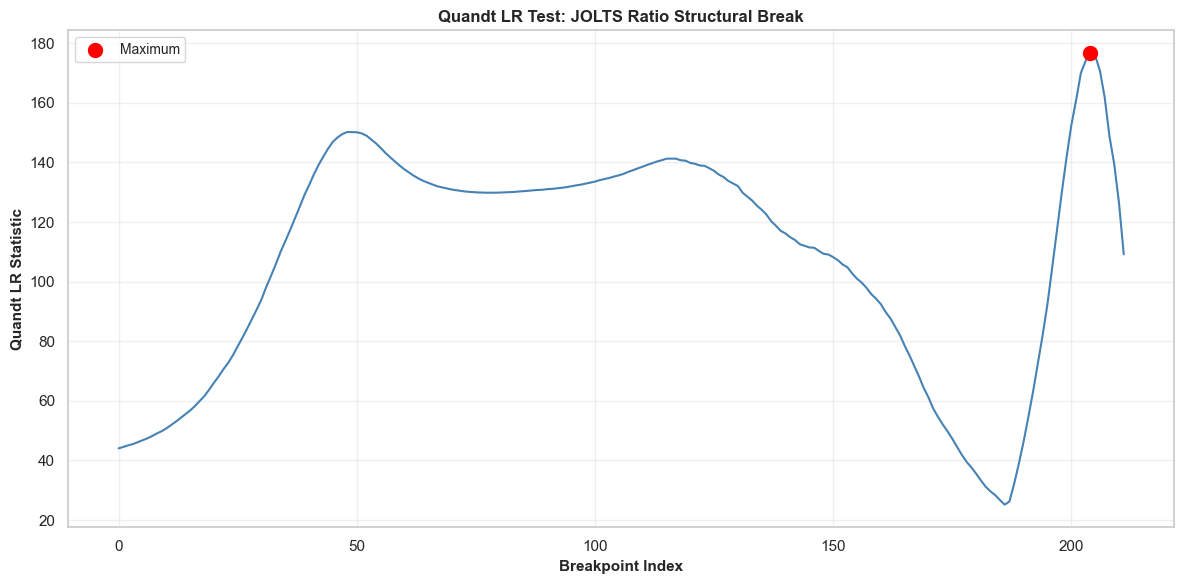

In [90]:
jolts_clean = df[["jolts_ratio", "date"]].dropna()
jolts_array = jolts_clean["jolts_ratio"].values

t_array = np.arange(len(jolts_array))
 
jolts_quandt = quandt_lr_test(jolts_array, t_array, trim_pct=0.15)
 
if jolts_quandt:
    breakpoint_idx = jolts_quandt["optimal_breakpoint_idx"]
    breakpoint_date = jolts_clean.iloc[breakpoint_idx]["date"]
    lr_stat = jolts_quandt["max_lr_statistic"]
 
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(range(len(jolts_quandt["all_breakpoints"])), jolts_quandt["all_lr_stats"],
           linewidth=1.5, color="steelblue")
    max_idx = np.argmax(jolts_quandt["all_lr_stats"])
    ax.scatter([max_idx], [max(jolts_quandt["all_lr_stats"])], color="red", s=100, zorder=5, label="Maximum")
    ax.set_xlabel("Breakpoint Index", fontsize=11, fontweight="bold")
    ax.set_ylabel("Quandt LR Statistic", fontsize=11, fontweight="bold")
    ax.set_title("Quandt LR Test: JOLTS Ratio Structural Break", fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig(figures_dir / "03_quandt_lr_test.png", dpi=300, bbox_inches="tight")

## CUSUM Analysis

In [79]:
def cusum_analysis(series):
    demeaned = series - np.nanmean(series)
    standardized = demeaned / np.nanstd(series)
    cusum_pos = np.zeros_like(standardized)
    cusum_neg = np.zeros_like(standardized)
 
    for i in range(1, len(standardized)):
        cusum_pos[i] = max(0, cusum_pos[i - 1] + standardized[i])
        cusum_neg[i] = min(0, cusum_neg[i - 1] + standardized[i])
 
    return cusum_pos, cusum_neg
 
jolts_series = df["jolts_ratio"].dropna().values
cusum_pos_jolts, cusum_neg_jolts = cusum_analysis(jolts_series)
 
ahe_series = df["ahe_private_12m_pct"].dropna().values
cusum_pos_ahe, cusum_neg_ahe = cusum_analysis(ahe_series)
 
cpi_series = df["cpi_all_12m_pct"].dropna().values
cusum_pos_cpi, cusum_neg_cpi = cusum_analysis(cpi_series)

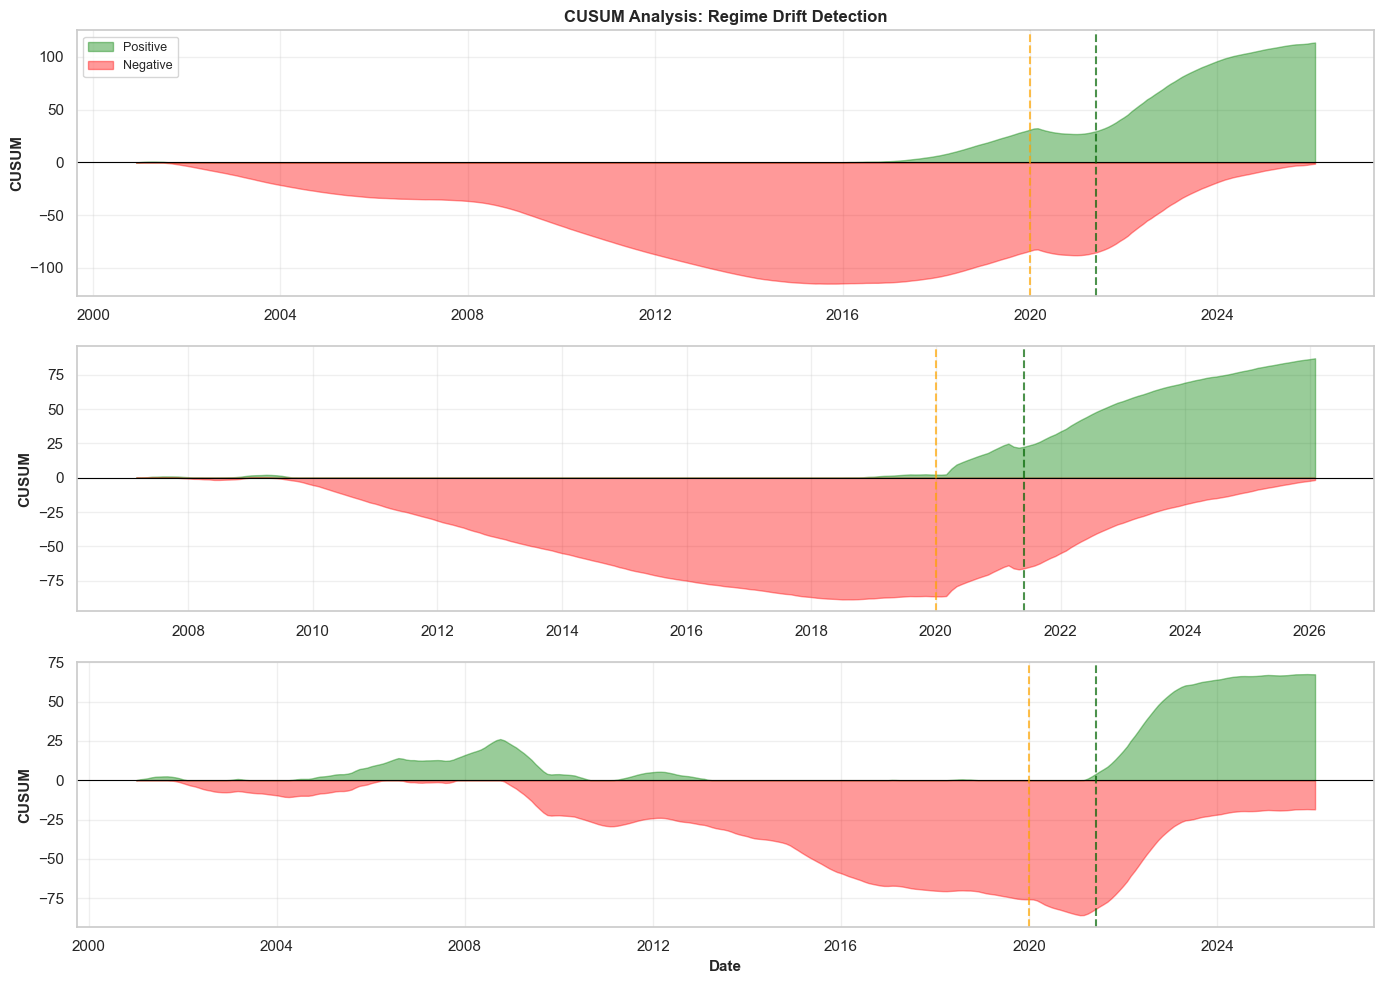

In [91]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
 
jolts_dates = df["date"][df["jolts_ratio"].notna()].values
ahe_dates = df["date"][df["ahe_private_12m_pct"].notna()].values
cpi_dates = df["date"][df["cpi_all_12m_pct"].notna()].values
 
axes[0].fill_between(jolts_dates, 0, cusum_pos_jolts, alpha=0.4, color="green", label="Positive")
axes[0].fill_between(jolts_dates, 0, cusum_neg_jolts, alpha=0.4, color="red", label="Negative")
axes[0].axhline(0, color="black", linestyle="-", linewidth=0.8)
axes[0].axvline(pre_2020_cutoff, color="orange", linestyle="--", linewidth=1.5, alpha=0.7)
axes[0].axvline(recovery_threshold, color="darkgreen", linestyle="--", linewidth=1.5, alpha=0.7)
axes[0].set_ylabel("CUSUM", fontsize=11, fontweight="bold")
axes[0].set_title("CUSUM Analysis: Regime Drift Detection", fontsize=12, fontweight="bold")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].grid(True, alpha=0.3)
 
axes[1].fill_between(ahe_dates, 0, cusum_pos_ahe, alpha=0.4, color="green", label="Positive")
axes[1].fill_between(ahe_dates, 0, cusum_neg_ahe, alpha=0.4, color="red", label="Negative")
axes[1].axhline(0, color="black", linestyle="-", linewidth=0.8)
axes[1].axvline(pre_2020_cutoff, color="orange", linestyle="--", linewidth=1.5, alpha=0.7)
axes[1].axvline(recovery_threshold, color="darkgreen", linestyle="--", linewidth=1.5, alpha=0.7)
axes[1].set_ylabel("CUSUM", fontsize=11, fontweight="bold")
axes[1].grid(True, alpha=0.3)
 
axes[2].fill_between(cpi_dates, 0, cusum_pos_cpi, alpha=0.4, color="green", label="Positive")
axes[2].fill_between(cpi_dates, 0, cusum_neg_cpi, alpha=0.4, color="red", label="Negative")
axes[2].axhline(0, color="black", linestyle="-", linewidth=0.8)
axes[2].axvline(pre_2020_cutoff, color="orange", linestyle="--", linewidth=1.5, alpha=0.7)
axes[2].axvline(recovery_threshold, color="darkgreen", linestyle="--", linewidth=1.5, alpha=0.7)
axes[2].set_ylabel("CUSUM", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Date", fontsize=11, fontweight="bold")
axes[2].grid(True, alpha=0.3)
 
plt.tight_layout()
# plt.savefig(figures_dir / "03_cusum_analysis.png", dpi=300, bbox_inches="tight")

## Phillips Curve Analysis

In [92]:
phillips_results = []
 
for regime_name, regime_data in [("Pre-2020", df[df["date"] < pre_2020_cutoff]),
                                  ("Post-Pandemic (2021+)", df[df["date"] >= recovery_threshold])]:
    regime_df = regime_data[["cpi_all_12m_pct", "unemployment_rate"]].dropna()
 
    if len(regime_df) > 10:
        X = np.column_stack([np.ones(len(regime_df)), regime_df["unemployment_rate"]])
        y = regime_df["cpi_all_12m_pct"].values
 
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        residuals = y - X @ beta
        sigma_sq = np.sum(residuals**2) / (len(y) - 2)
        var_beta = sigma_sq * np.linalg.inv(X.T @ X)
        se_beta = np.sqrt(np.diag(var_beta))
        t_stats = beta / se_beta
        p_values = 2 * (1 - t_dist.cdf(np.abs(t_stats), len(y) - 2))
 
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - y.mean())**2)
        r_squared = 1 - (ss_res / ss_tot)
 
        phillips_results.append({
            "regime": regime_name,
            "intercept": round(beta[0], 4),
            "unemployment_coef": round(beta[1], 4),
            "unemployment_se": round(se_beta[1], 4),
            "unemployment_t": round(t_stats[1], 4),
            "unemployment_p": round(p_values[1], 4),
            "r_squared": round(r_squared, 4),
            "n_obs": len(y),
        })
 
phillips_df = pd.DataFrame(phillips_results)
# phillips_df.to_csv(processed_data_dir / "03_phillips_curve.csv", index=False)

In [93]:
enhanced_phillips_results = []
 
for regime_name, regime_data in [("Pre-2020", df[df["date"] < pre_2020_cutoff]),
                                  ("Post-Pandemic (2021+)", df[df["date"] >= recovery_threshold])]:
    regime_df = regime_data[["cpi_all_12m_pct", "unemployment_rate"]].dropna()
    
    if len(regime_df) > 10:
        regime_df_lagged = regime_df.copy()
        regime_df_lagged["cpi_lagged"] = regime_df["cpi_all_12m_pct"].shift(1)
        regime_df_lagged = regime_df_lagged.dropna()
        
        X = np.column_stack([np.ones(len(regime_df_lagged)), 
                            regime_df_lagged["unemployment_rate"],
                            regime_df_lagged["cpi_lagged"]])
        y = regime_df_lagged["cpi_all_12m_pct"].values
        
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        residuals = y - X @ beta
        sigma_sq = np.sum(residuals**2) / (len(y) - 3)
        var_beta = sigma_sq * np.linalg.inv(X.T @ X)
        se_beta = np.sqrt(np.diag(var_beta))
        t_stats = beta / se_beta
        p_values = 2 * (1 - t_dist.cdf(np.abs(t_stats), len(y) - 3))
        
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - y.mean())**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        enhanced_phillips_results.append({
            "regime": regime_name,
            "intercept": round(beta[0], 4),
            "intercept_se": round(se_beta[0], 4),
            "intercept_t": round(t_stats[0], 4),
            "intercept_p": round(p_values[0], 4),
            "unemployment_coef": round(beta[1], 4),
            "unemployment_se": round(se_beta[1], 4),
            "unemployment_t": round(t_stats[1], 4),
            "unemployment_p": round(p_values[1], 4),
            "lagged_inflation_coef": round(beta[2], 4),
            "lagged_inflation_se": round(se_beta[2], 4),
            "lagged_inflation_t": round(t_stats[2], 4),
            "lagged_inflation_p": round(p_values[2], 4),
            "r_squared": round(r_squared, 4),
            "n_obs": len(y),
        })
 
enhanced_phillips_df = pd.DataFrame(enhanced_phillips_results)
# enhanced_phillips_df.to_csv(processed_data_dir / "03_enhanced_phillips_curve.csv", index=False)

## Lag Structure Analysis

In [94]:
lag_analysis_results = []
 
for lag_months in [0, 3, 6, 12, 24]:
    df_lag = df[["jolts_ratio", "ahe_private_12m_pct"]].copy()
    df_lag["ahe_forward"] = df_lag["ahe_private_12m_pct"].shift(-lag_months)
 
    corr_pre_2020 = df_lag[df["date"] < pre_2020_cutoff]["jolts_ratio"].corr(
        df_lag[df["date"] < pre_2020_cutoff]["ahe_forward"]
    )
 
    corr_post_2020 = df_lag[df["date"] >= recovery_threshold]["jolts_ratio"].corr(
        df_lag[df["date"] >= recovery_threshold]["ahe_forward"]
    )
 
    lag_analysis_results.append({
        "lag_months": lag_months,
        "pre_2020_correlation": round(corr_pre_2020, 4),
        "post_2020_correlation": round(corr_post_2020, 4),
        "correlation_change": round(corr_post_2020 - corr_pre_2020, 4),
    })
 
lag_analysis_df = pd.DataFrame(lag_analysis_results)
# lag_analysis_df.to_csv(processed_data_dir / "03_lag_analysis.csv", index=False)

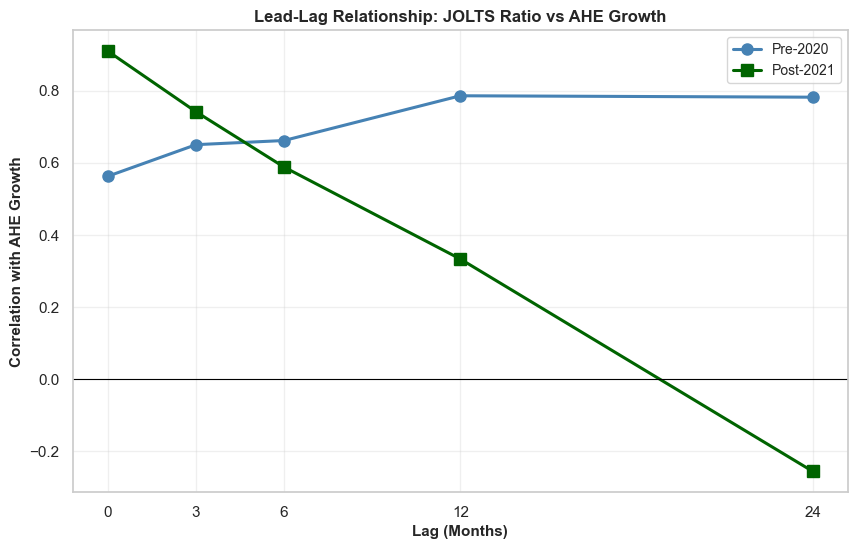

In [95]:
fig, ax = plt.subplots(figsize=(10, 6))
 
ax.plot(lag_analysis_df["lag_months"], lag_analysis_df["pre_2020_correlation"],
       marker="o", linewidth=2.2, markersize=8, label="Pre-2020", color="steelblue")
ax.plot(lag_analysis_df["lag_months"], lag_analysis_df["post_2020_correlation"],
       marker="s", linewidth=2.2, markersize=8, label="Post-2021", color="darkgreen")
ax.axhline(0, color="black", linestyle="-", linewidth=0.8)
ax.set_xlabel("Lag (Months)", fontsize=11, fontweight="bold")
ax.set_ylabel("Correlation with AHE Growth", fontsize=11, fontweight="bold")
ax.set_title("Lead-Lag Relationship: JOLTS Ratio vs AHE Growth", fontsize=12, fontweight="bold")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(lag_analysis_df["lag_months"])
 
# plt.savefig(figures_dir / "03_lag_structure_wage.png", dpi=300, bbox_inches="tight")

## Rolling Regression Coefficients

In [85]:
def rolling_regression_coefficients(df, y_col, x_col, window=24):
    df_clean = df[[y_col, x_col]].dropna()
    coefficients = []
    r_squared = []
 
    for i in range(window, len(df_clean)):
        y_window = df_clean[y_col].iloc[i-window:i].values
        x_window = df_clean[x_col].iloc[i-window:i].values
 
        X = np.column_stack([np.ones(len(x_window)), x_window])
        beta = np.linalg.lstsq(X, y_window, rcond=None)[0]
 
        y_pred = X @ beta
        ss_res = np.sum((y_window - y_pred) ** 2)
        ss_tot = np.sum((y_window - y_window.mean()) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
 
        coefficients.append(beta[1])
        r_squared.append(r2)
 
    return np.array(coefficients), np.array(r_squared)
 
coef_ahe, r2_ahe = rolling_regression_coefficients(df, "ahe_private_12m_forward", "log_jolts_ratio", window=24)
coef_cpi, r2_cpi = rolling_regression_coefficients(df, "cpi_all_12m_forward", "log_jolts_ratio", window=24)

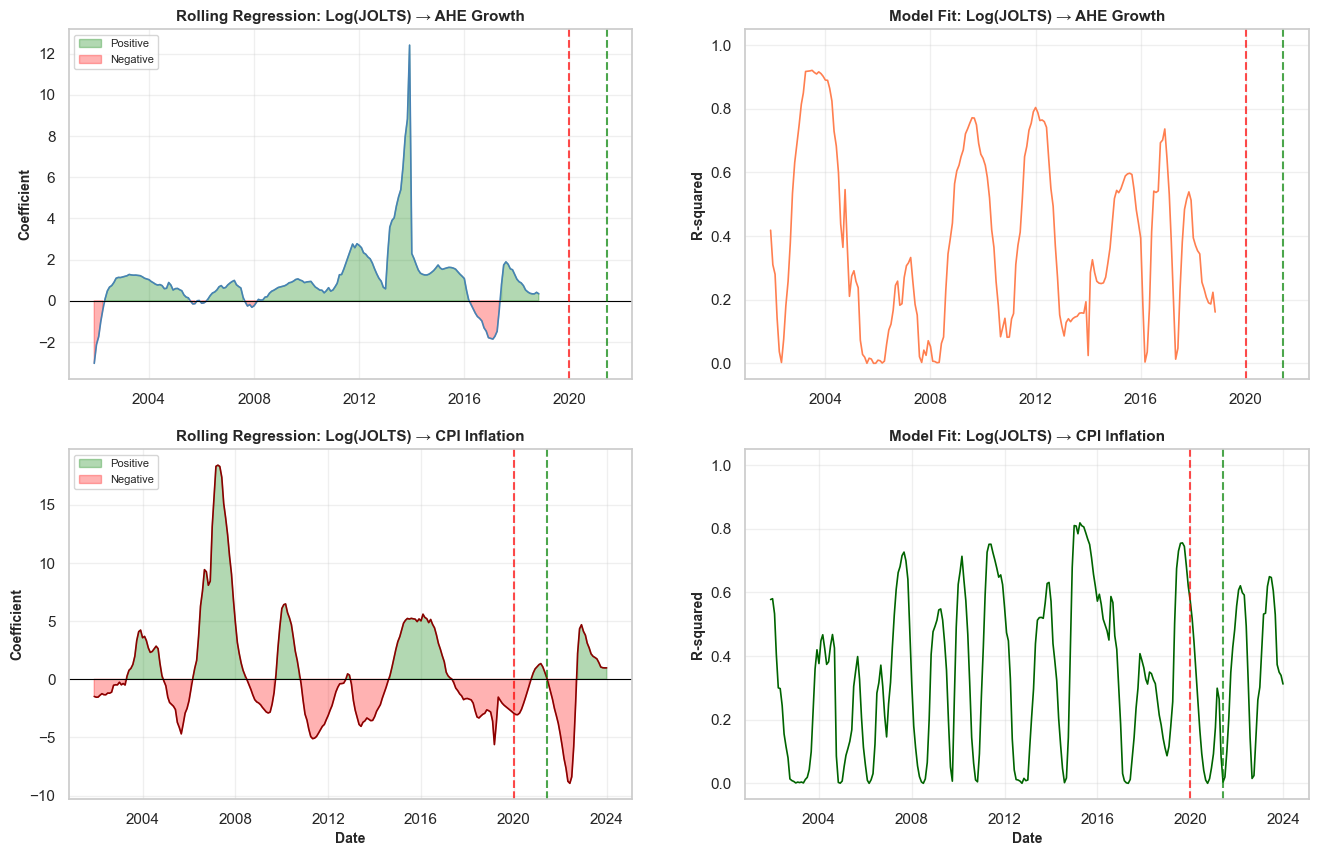

In [96]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
 
df_rolling_window = df.iloc[23:]
 
axes[0, 0].plot(df_rolling_window["date"].iloc[:len(coef_ahe)], coef_ahe, linewidth=1.2, color="steelblue")
axes[0, 0].axhline(0, color="black", linestyle="-", linewidth=0.8)
axes[0, 0].axvline(pre_2020_cutoff, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
axes[0, 0].axvline(recovery_threshold, color="green", linestyle="--", linewidth=1.5, alpha=0.7)
axes[0, 0].fill_between(df_rolling_window["date"].iloc[:len(coef_ahe)], 0, coef_ahe,
                        where=(coef_ahe > 0), alpha=0.3, color="green", label="Positive")
axes[0, 0].fill_between(df_rolling_window["date"].iloc[:len(coef_ahe)], 0, coef_ahe,
                        where=(coef_ahe <= 0), alpha=0.3, color="red", label="Negative")
axes[0, 0].set_ylabel("Coefficient", fontsize=10, fontweight="bold")
axes[0, 0].set_title("Rolling Regression: Log(JOLTS) → AHE Growth", fontsize=11, fontweight="bold")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)
 
axes[0, 1].plot(df_rolling_window["date"].iloc[:len(r2_ahe)], r2_ahe, linewidth=1.2, color="coral")
axes[0, 1].axvline(pre_2020_cutoff, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
axes[0, 1].axvline(recovery_threshold, color="green", linestyle="--", linewidth=1.5, alpha=0.7)
axes[0, 1].set_ylabel("R-squared", fontsize=10, fontweight="bold")
axes[0, 1].set_title("Model Fit: Log(JOLTS) → AHE Growth", fontsize=11, fontweight="bold")
axes[0, 1].set_ylim(-0.05, 1.05)
axes[0, 1].grid(True, alpha=0.3)
 
axes[1, 0].plot(df_rolling_window["date"].iloc[:len(coef_cpi)], coef_cpi, linewidth=1.2, color="darkred")
axes[1, 0].axhline(0, color="black", linestyle="-", linewidth=0.8)
axes[1, 0].axvline(pre_2020_cutoff, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
axes[1, 0].axvline(recovery_threshold, color="green", linestyle="--", linewidth=1.5, alpha=0.7)
axes[1, 0].fill_between(df_rolling_window["date"].iloc[:len(coef_cpi)], 0, coef_cpi,
                        where=(coef_cpi > 0), alpha=0.3, color="green", label="Positive")
axes[1, 0].fill_between(df_rolling_window["date"].iloc[:len(coef_cpi)], 0, coef_cpi,
                        where=(coef_cpi <= 0), alpha=0.3, color="red", label="Negative")
axes[1, 0].set_ylabel("Coefficient", fontsize=10, fontweight="bold")
axes[1, 0].set_xlabel("Date", fontsize=10, fontweight="bold")
axes[1, 0].set_title("Rolling Regression: Log(JOLTS) → CPI Inflation", fontsize=11, fontweight="bold")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)
 
axes[1, 1].plot(df_rolling_window["date"].iloc[:len(r2_cpi)], r2_cpi, linewidth=1.2, color="darkgreen")
axes[1, 1].axvline(pre_2020_cutoff, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
axes[1, 1].axvline(recovery_threshold, color="green", linestyle="--", linewidth=1.5, alpha=0.7)
axes[1, 1].set_ylabel("R-squared", fontsize=10, fontweight="bold")
axes[1, 1].set_xlabel("Date", fontsize=10, fontweight="bold")
axes[1, 1].set_title("Model Fit: Log(JOLTS) → CPI Inflation", fontsize=11, fontweight="bold")
axes[1, 1].set_ylim(-0.05, 1.05)
axes[1, 1].grid(True, alpha=0.3)
 
# plt.savefig(figures_dir / "03_rolling_regression_coefficients.png", dpi=300, bbox_inches="tight")

## Dynamic Rolling Correlations at Multiple Lags

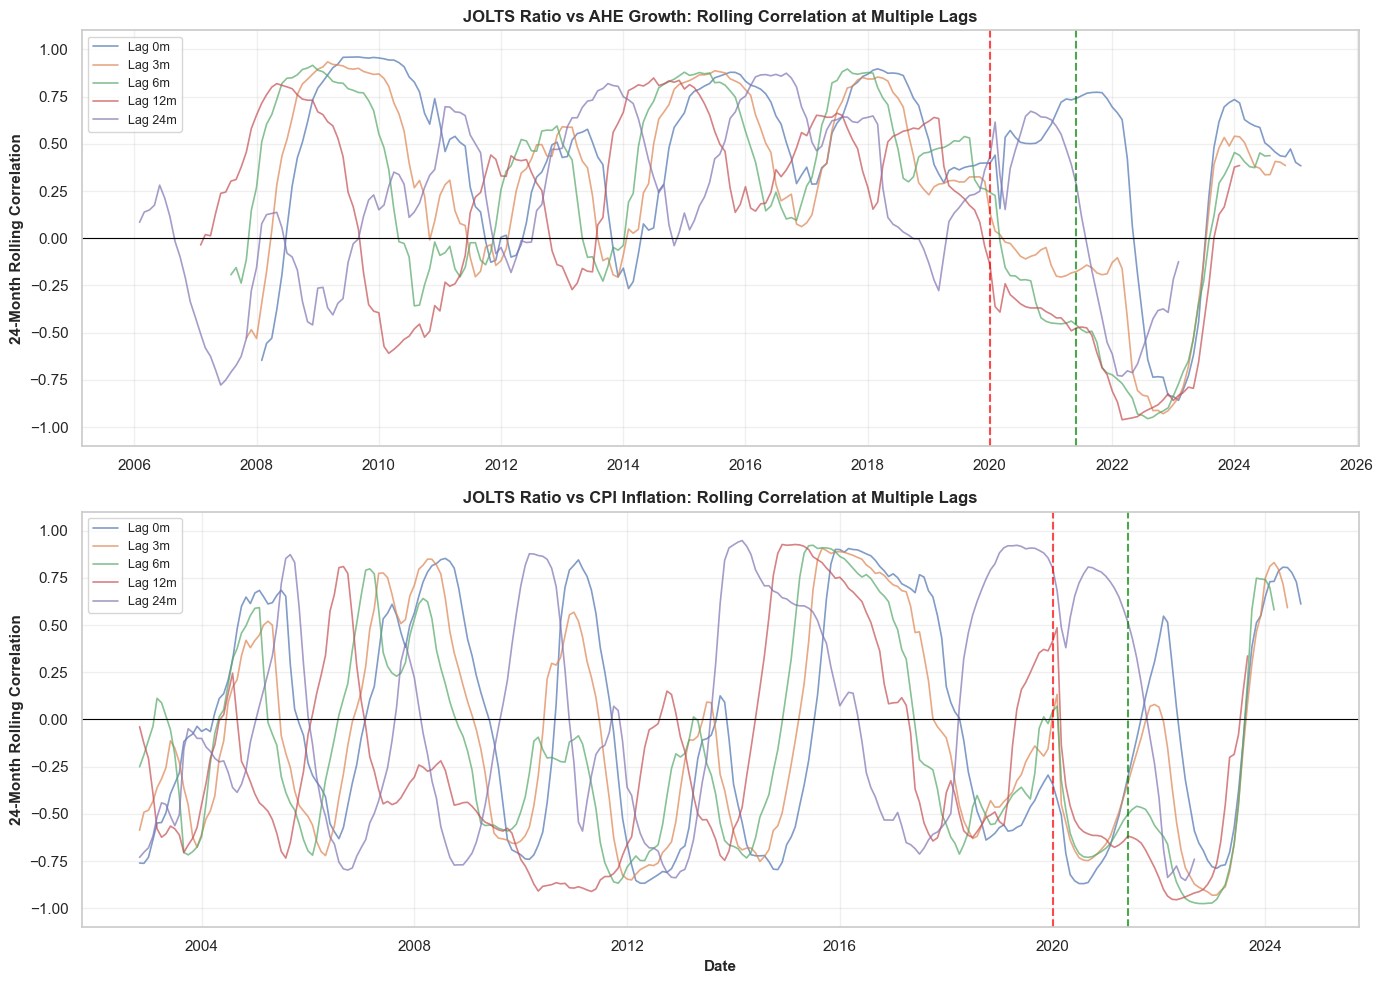

In [97]:
rolling_window = 24
lag_months_list = [0, 3, 6, 12, 24]
 
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
 
for lag in lag_months_list:
    df_lag_corr = df[["date", "log_jolts_ratio", "ahe_private_12m_forward"]].copy()
    df_lag_corr["ahe_lagged"] = df_lag_corr["ahe_private_12m_forward"].shift(-lag)
    df_lag_corr["rolling_corr"] = df_lag_corr["log_jolts_ratio"].rolling(
        window=rolling_window
    ).corr(df_lag_corr["ahe_lagged"])
    
    axes[0].plot(df_lag_corr["date"], df_lag_corr["rolling_corr"], linewidth=1.2, label=f"Lag {lag}m", alpha=0.7)
 
axes[0].axhline(0, color="black", linestyle="-", linewidth=0.8)
axes[0].axvline(pre_2020_cutoff, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
axes[0].axvline(recovery_threshold, color="green", linestyle="--", linewidth=1.5, alpha=0.7)
axes[0].set_ylabel(f"{rolling_window}-Month Rolling Correlation", fontsize=11, fontweight="bold")
axes[0].set_title("JOLTS Ratio vs AHE Growth: Rolling Correlation at Multiple Lags", fontsize=12, fontweight="bold")
axes[0].legend(loc="best", fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-1.1, 1.1)
 
for lag in lag_months_list:
    df_lag_corr_infl = df[["date", "log_jolts_ratio", "cpi_all_12m_forward"]].copy()
    df_lag_corr_infl["cpi_lagged"] = df_lag_corr_infl["cpi_all_12m_forward"].shift(-lag)
    df_lag_corr_infl["rolling_corr"] = df_lag_corr_infl["log_jolts_ratio"].rolling(
        window=rolling_window
    ).corr(df_lag_corr_infl["cpi_lagged"])
    
    axes[1].plot(df_lag_corr_infl["date"], df_lag_corr_infl["rolling_corr"], linewidth=1.2, label=f"Lag {lag}m", alpha=0.7)
 
axes[1].axhline(0, color="black", linestyle="-", linewidth=0.8)
axes[1].axvline(pre_2020_cutoff, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
axes[1].axvline(recovery_threshold, color="green", linestyle="--", linewidth=1.5, alpha=0.7)
axes[1].set_ylabel(f"{rolling_window}-Month Rolling Correlation", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Date", fontsize=11, fontweight="bold")
axes[1].set_title("JOLTS Ratio vs CPI Inflation: Rolling Correlation at Multiple Lags", fontsize=12, fontweight="bold")
axes[1].legend(loc="best", fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-1.1, 1.1)
 
plt.tight_layout()
# plt.savefig(figures_dir / "03_dynamic_rolling_correlations_multilags.png", dpi=300, bbox_inches="tight")

## Summary

In [89]:
summary_audit = pd.DataFrame([
    {"metric": "total_observations", "value": len(df)},
    {"metric": "total_engineered_features", "value": len(df.columns)},
    {"metric": "date_range_start", "value": str(df["date"].min().date())},
    {"metric": "date_range_end", "value": str(df["date"].max().date())},
    {"metric": "pre_2020_observations", "value": len(pre_2020_data)},
    {"metric": "pandemic_shock_observations", "value": len(df[(df["date"] >= pre_2020_cutoff) & (df["date"] < recovery_threshold)])},
    {"metric": "post_2021_observations", "value": len(post_2020_data)},
    {"metric": "complete_cases_pct", "value": round(complete_cases_pct, 2)},
])
 
summary_audit

,metric,value
0,total_observations,315
1,total_engineered_features,150
2,date_range_start,2000-01-01
3,date_range_end,2026-03-01
4,pre_2020_observations,240
5,pandemic_shock_observations,17
6,post_2021_observations,58
7,complete_cases_pct,9.84
